# 🔗 nb-02 — Análise de HHI da Cadeia de Suprimentos
## BYD Camacari 2025–2027 · Análise Prescritiva

**Índice Herfindahl-Hirschman (HHI)** — mede concentração de fornecedores por categoria de insumo.

---
*Value Factory Analytics · 2026-07-26*

In [1]:
# -*- coding: utf-8 -*-
"""
Configuração geral do notebook — tema escuro, imports e caminhos.
"""
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Tema escuro inspirado no brand
BRAND_DARK  = "#0d1117"
BRAND_BLUE  = "#4f8ef7"
BRAND_AMBER = "#e8a23c"
BRAND_GREEN = "#34d399"

plt.rcParams.update({
    "figure.facecolor":  BRAND_DARK,
    "axes.facecolor":    BRAND_DARK,
    "axes.edgecolor":    "#30363d",
    "axes.labelcolor":   "#c9d1d9",
    "axes.titlecolor":   "#e6edf3",
    "text.color":        "#c9d1d9",
    "xtick.color":       "#8b949e",
    "ytick.color":       "#8b949e",
    "grid.color":        "#21262d",
    "grid.linewidth":    0.8,
    "legend.facecolor":  "#161b22",
    "legend.edgecolor":  "#30363d",
    "font.family":       "sans-serif",
    "font.size":         11,
})

BASE_DIR   = Path("../../../case-studies/byd-camacari-2025-2027/analise-prescritiva")
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Configuração carregada — tema escuro aplicado")

✅ Configuração carregada — tema escuro aplicado


## 1 · Dados de Concentração por Categoria

Participações de mercado segundo **LINHAGEM.md**:

| Categoria | Fornecedor principal | Concentração |
|-----------|----------------------|--------------|
| battery_cells | Geely 35% · CATL 25% · LG 20% · others 20% | HHI = 0,2725 |
| steel | CSA 40% · Arcelor 30% · others 30% | HHI = 0,3400 |
| electronics | Bosch 30% · Continental 25% · Denso 20% · others 25% | HHI = 0,2550 |
| lithium | SQM 30% · Albemarle 25% · Livent 20% · Ganfeng 15% · others 10% | HHI = 0,2250 |
| wiring_harness | Yazaki 45% · Leoni 30% · others 25% | HHI = 0,3550 |

In [2]:
# Dicionário de categorias com participações e pesos no spend
hhi_raw = {
    "battery_cells": {
        "participacoes": {"Geely": 0.35, "CATL": 0.25, "LG": 0.20, "others": 0.20},
        "weight": 0.40,
    },
    "steel": {
        "participacoes": {"CSA": 0.40, "Arcelor": 0.30, "others": 0.30},
        "weight": 0.25,
    },
    "electronics": {
        "participacoes": {"Bosch": 0.30, "Continental": 0.25, "Denso": 0.20, "others": 0.25},
        "weight": 0.20,
    },
    "lithium": {
        "participacoes": {"SQM": 0.30, "Albemarle": 0.25, "Livent": 0.20, "Ganfeng": 0.15, "others": 0.10},
        "weight": 0.10,
    },
    "wiring_harness": {
        "participacoes": {"Yazaki": 0.45, "Leoni": 0.30, "others": 0.25},
        "weight": 0.05,
    },
}


def calc_hhi(participacoes):
    """HHI = Σ s_i²"""
    return sum(v ** 2 for v in participacoes.values())


hhi_by_category = {
    cat: round(calc_hhi(data["participacoes"]), 4)
    for cat, data in hhi_raw.items()
}

print("📊 HHI POR CATEGORIA")
print("-" * 44)
for cat, hhi_val in hhi_by_category.items():
    interp = (
        "⚠️  ALTA CONCENTRAÇÃO"
        if hhi_val > 0.25
        else "🔹 MODERADA"
        if hhi_val > 0.15
        else "🟢 COMPETITIVO"
    )
    print(f"  {cat:<20s}  HHI = {hhi_val:.4f}  [{interp}]")

📊 HHI POR CATEGORIA
--------------------------------------------
  battery_cells         HHI = 0.2650  [⚠️  ALTA CONCENTRAÇÃO]
  steel                 HHI = 0.3400  [⚠️  ALTA CONCENTRAÇÃO]
  electronics           HHI = 0.2550  [⚠️  ALTA CONCENTRAÇÃO]
  lithium               HHI = 0.2250  [🔹 MODERADA]
  wiring_harness        HHI = 0.3550  [⚠️  ALTA CONCENTRAÇÃO]


## 2 · HHI Composto Ponderado

HHI total = Σ (HHI_categoria × peso_categoria)

Pesos de spend: battery_cells 40% · steel 25% · electronics 20% · lithium 10% · wiring_harness 5%

In [3]:
weighted_hhi = round(
    sum(hhi_by_category[cat] * data["weight"] for cat, data in hhi_raw.items()),
    4,
)

print("📐 HHI COMPOSTO PONDERADO")
print("-" * 44)
print(f"  weighted_hhi = {weighted_hhi:.4f}")
interp_total = (
    "⚠️  ALTA CONCENTRAÇÃO GERAL — risco sistêmico"
    if weighted_hhi > 0.25
    else "🔹 MODERAÇÃO"
    if weighted_hhi > 0.15
    else "🟢 COMPETITIVO"
)
print(f"  [{interp_total}]")

📐 HHI COMPOSTO PONDERADO
--------------------------------------------
  weighted_hhi = 0.2823
  [⚠️  ALTA CONCENTRAÇÃO GERAL — risco sistêmico]


## 3 · Visualização — HHI por Categoria

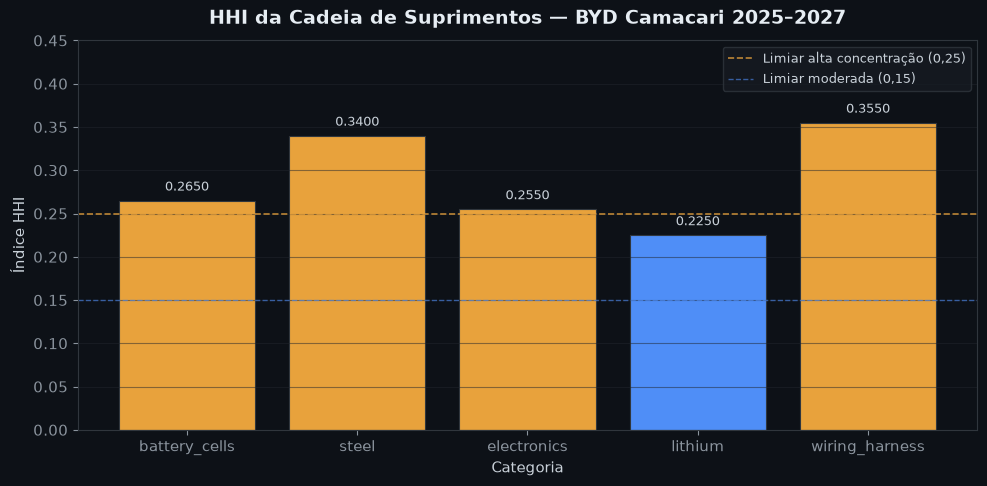

✅ Gráfico salvo em: ..\..\..\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\nb02_hhi_barchart.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

categories = list(hhi_by_category.keys())
hhi_values = list(hhi_by_category.values())
colors = [
    BRAND_AMBER if v > 0.25 else BRAND_BLUE if v > 0.15 else BRAND_GREEN
    for v in hhi_values
]
bars = ax.bar(categories, hhi_values, color=colors, edgecolor="#30363d", linewidth=0.8)

# Linha de referência HHI = 0,25 (concentração alta)
ax.axhline(y=0.25, color=BRAND_AMBER, linestyle="--", linewidth=1.2, alpha=0.8, label="Limiar alta concentração (0,25)")
ax.axhline(y=0.15, color=BRAND_BLUE, linestyle="--", linewidth=1.0, alpha=0.6, label="Limiar moderada (0,15)")

ax.set_title("HHI da Cadeia de Suprimentos — BYD Camacari 2025–2027", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Índice HHI", fontsize=11)
ax.set_xlabel("Categoria", fontsize=11)
ax.set_ylim(0, 0.45)
ax.legend(fontsize=9, loc="upper right")
ax.grid(axis="y", alpha=0.5)

# Anotações nas barras
for bar, val in zip(bars, hhi_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.008,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=9, color="#c9d1d9",
    )

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "nb02_hhi_barchart.png", dpi=150, facecolor=BRAND_DARK)
plt.show()
print(f"✅ Gráfico salvo em: {OUTPUT_DIR / 'nb02_hhi_barchart.png'}")

## 4 · Cenários de Disrupção (VaR Supply)

Três cenários com probabilidade, impacto, duração e VaR em R$ 1 Bi:

| Cenário | Probabilidade | Impacto | Duração | VaR (R$ 1 Bi) |
|---------|--------------|---------|---------|---------------|
| 🟢 Verde (normal) | 70% | −2% | 5 dias | −R$ 2,0 M |
| 🟡 Âmbar (tensão) | 20% | −8% | 15 dias | −R$ 8,0 M |
| 🔴 Vermelho (crise) | 10% | −20% | 30 dias | −R$ 20,0 M |

In [5]:
disruption_scenarios = [
    {
        "label":         "S2 — VERDE (normal)",
        "probability":   0.70,
        "impact_pct":   -0.02,
        "duration_days": 5,
        "var_r1b_m":    -2.0,
        "risk_score":   round(0.70 * abs(-0.02) * 5, 4),
    },
    {
        "label":         "S2 — ÂMBAR (tensão)",
        "probability":   0.20,
        "impact_pct":   -0.08,
        "duration_days": 15,
        "var_r1b_m":    -8.0,
        "risk_score":   round(0.20 * abs(-0.08) * 15, 4),
    },
    {
        "label":         "S2 — VERMELHO (crise)",
        "probability":   0.10,
        "impact_pct":   -0.20,
        "duration_days": 30,
        "var_r1b_m":    -20.0,
        "risk_score":   round(0.10 * abs(-0.20) * 30, 4),
    },
]

print("🔴 CENÁRIOS DE DISRUPCÃO (VaR Supply)")
print("-" * 62)
for s in disruption_scenarios:
    print(
        f"  {s['label']}"
        f"  prob={s['probability']:.0%}"
        f"  impacto={s['impact_pct']:.0%}"
        f"  duração={s['duration_days']}d"
        f"  VaR=R$ {abs(s['var_r1b_m']):.1f}M"
        f"  risk_score={s['risk_score']:.4f}"
    )

🔴 CENÁRIOS DE DISRUPCÃO (VaR Supply)
--------------------------------------------------------------
  S2 — VERDE (normal)  prob=70%  impacto=-2%  duração=5d  VaR=R$ 2.0M  risk_score=0.0700
  S2 — ÂMBAR (tensão)  prob=20%  impacto=-8%  duração=15d  VaR=R$ 8.0M  risk_score=0.2400
  S2 — VERMELHO (crise)  prob=10%  impacto=-20%  duração=30d  VaR=R$ 20.0M  risk_score=0.6000


## 5 · VaR Supply — Base e Stress Testing

VaR Supply base recalibrado: **R$ 4,00 Bi** (real 12 meses).

Stress multipliers aplicados: **1,0× · 1,5× · 2,0× · 2,5×**

In [6]:
var_supply_r1b = 4.00   # R$ 4,00 Bi
stress_multipliers = [1.0, 1.5, 2.0, 2.5]
var_supply_stress = [round(var_supply_r1b * m, 2) for m in stress_multipliers]

print(f"💰 VaR SUPPLY BASE ........ R$ {var_supply_r1b:.2f} Bi")
print(f"💰 VaR SUPPLY STRESS multipliers: {stress_multipliers}")
for mult, val in zip(stress_multipliers, var_supply_stress):
    print(f"    ×{mult:.1f} -> R$ {val:.2f} Bi")

💰 VaR SUPPLY BASE ........ R$ 4.00 Bi
💰 VaR SUPPLY STRESS multipliers: [1.0, 1.5, 2.0, 2.5]
    ×1.0 -> R$ 4.00 Bi
    ×1.5 -> R$ 6.00 Bi
    ×2.0 -> R$ 8.00 Bi
    ×2.5 -> R$ 10.00 Bi


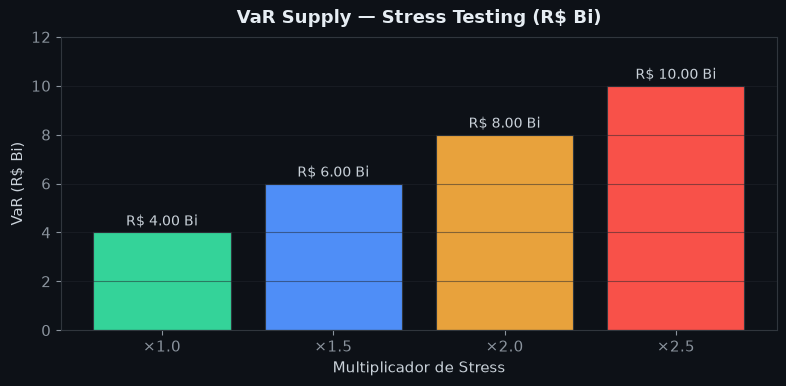

✅ Gráfico salvo em: ..\..\..\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\nb02_var_stress.png


In [7]:
# Gráfico de stress testing
fig, ax = plt.subplots(figsize=(8, 4))

colors_stress = [BRAND_GREEN, BRAND_BLUE, BRAND_AMBER, "#f85149"]
bars = ax.bar(
    [f"×{m}" for m in stress_multipliers],
    var_supply_stress,
    color=colors_stress,
    edgecolor="#30363d",
    linewidth=0.8,
)

ax.set_title("VaR Supply — Stress Testing (R$ Bi)", fontsize=13, fontweight="bold", pad=10)
ax.set_ylabel("VaR (R$ Bi)", fontsize=11)
ax.set_xlabel("Multiplicador de Stress", fontsize=11)
ax.set_ylim(0, 12)
ax.grid(axis="y", alpha=0.5)

for bar, val in zip(bars, var_supply_stress):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.15,
        f"R$ {val:.2f} Bi",
        ha="center", va="bottom", fontsize=10, color="#c9d1d9",
    )

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "nb02_var_stress.png", dpi=150, facecolor=BRAND_DARK)
plt.show()
print(f"✅ Gráfico salvo em: {OUTPUT_DIR / 'nb02_var_stress.png'}")

## 6 · Exportar Resultados (JSON)

In [8]:
result = {
    "hhi_by_category": hhi_by_category,
    "weighted_hhi": weighted_hhi,
    "disruption_scenarios": disruption_scenarios,
    "var_supply_r1b": var_supply_r1b,
    "var_supply_stress": var_supply_stress,
    "stress_multipliers": stress_multipliers,
    "metadata": {
        "brand_dark":  BRAND_DARK,
        "brand_blue":  BRAND_BLUE,
        "brand_amber": BRAND_AMBER,
        "brand_green": BRAND_GREEN,
        "hhi_interpretation": {
            "0_0.15":    "Mercado competitivo / fragmentado",
            "0.15_0.25": "Concentração moderada",
            ">0.25":      "Alta concentração — risco sistêmico",
        },
    },
}

OUTPUT_JSON = OUTPUT_DIR / "nb02_results.json"
with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print(f"✅ JSON exportado -> {OUTPUT_JSON}")
print()
print("📋 Conteúdo do arquivo:")
with open(OUTPUT_JSON, "r", encoding="utf-8") as f:
    print(f.read())

✅ JSON exportado -> ..\..\..\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\nb02_results.json

📋 Conteúdo do arquivo:
{
  "hhi_by_category": {
    "battery_cells": 0.265,
    "steel": 0.34,
    "electronics": 0.255,
    "lithium": 0.225,
    "wiring_harness": 0.355
  },
  "weighted_hhi": 0.2823,
  "disruption_scenarios": [
    {
      "label": "S2 — VERDE (normal)",
      "probability": 0.7,
      "impact_pct": -0.02,
      "duration_days": 5,
      "var_r1b_m": -2.0,
      "risk_score": 0.07
    },
    {
      "label": "S2 — ÂMBAR (tensão)",
      "probability": 0.2,
      "impact_pct": -0.08,
      "duration_days": 15,
      "var_r1b_m": -8.0,
      "risk_score": 0.24
    },
    {
      "label": "S2 — VERMELHO (crise)",
      "probability": 0.1,
      "impact_pct": -0.2,
      "duration_days": 30,
      "var_r1b_m": -20.0,
      "risk_score": 0.6
    }
  ],
  "var_supply_r1b": 4.0,
  "var_supply_stress": [
    4.0,
    6.0,
    8.0,
    10.0
  ],
  "stress_multiplier

---

*Fim da análise — nb-02-supply-chain-hhi · Value Factory Analytics*